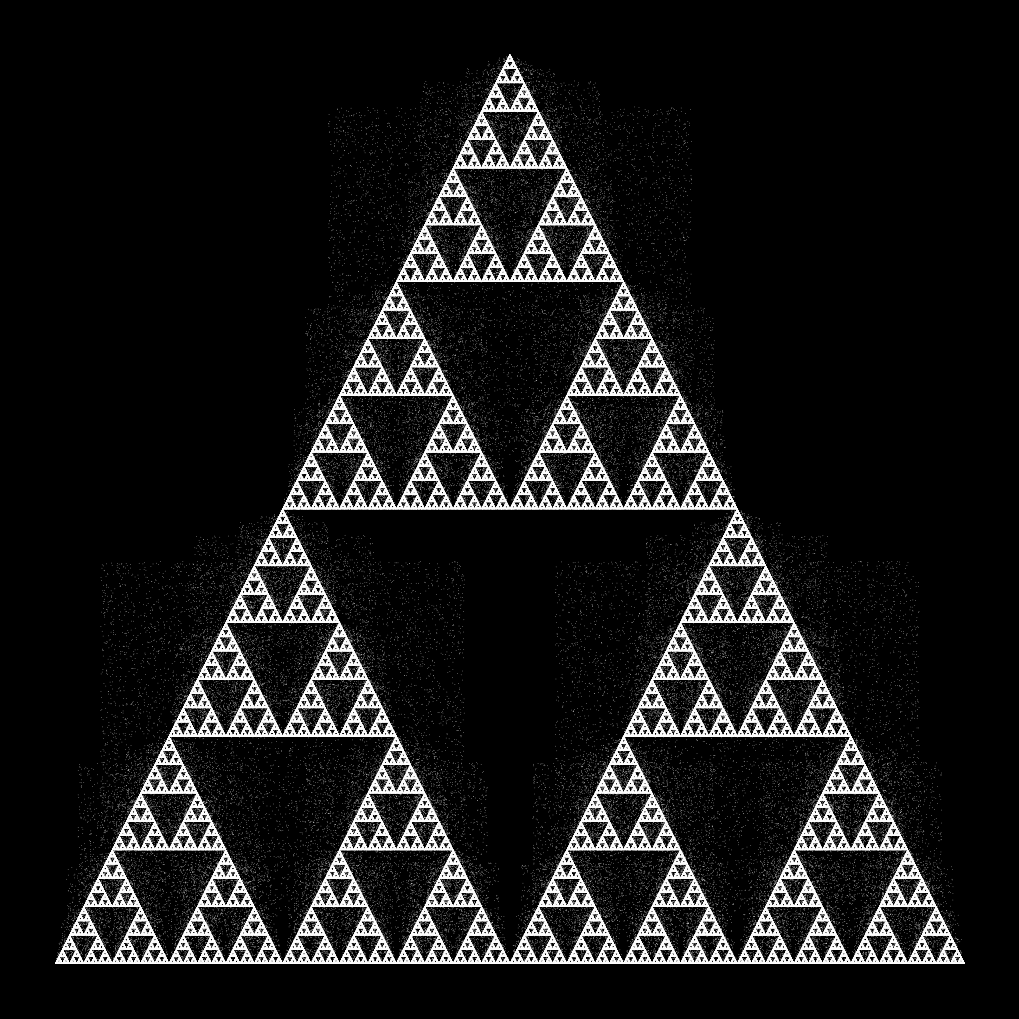

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import math

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#p = [(0,0), (1,0), (0.5, math.sqrt(3)/2)]

# Define 3 points
p = torch.tensor([
    [0.0, 0.0],
    [1.0, 0.0],
    [0.5, math.sqrt(3)/2],
], dtype=torch.float32, device=device)

# Bounds
x_max, x_min = 0.9, 0.1
y_max, y_min = math.sqrt(3)/2 - 0.1, 0.1

N = 20000

# Random starting points
v_x = (x_min + (x_max - x_min) *torch.rand(N, device=device))
v_y = (y_min + (y_max - y_min) *torch.rand(N, device=device))
v = torch.stack([v_x, v_y], dim=1)

v = v.to(device)
p = p.to(device)

# Calculate v_(n + 1)
def vn(v):
    choice = torch.randint(0, 3, (v.shape[0],), device=device)
    p_rand = p[choice]                
    return 0.5 * (v + p_rand)

xs, ys = [], []
iterations = 100

for i in range(iterations):
    v = vn(v)
    xs.append(v[:, 0])
    ys.append(v[:, 1])

x = torch.cat(xs).numpy()
y = torch.cat(ys).numpy()

plt.figure(figsize=(10, 10))
plt.scatter(x, y, color="white", s=0.2, edgecolors='none')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()